# 第43课 · 给声音装上时间轴——STFT（短时傅里叶变换）与时频分辨率的永恒取舍（tradeoff）

**目标**：理解 STFT 如何把 1D 信号变成 2D 时频矩阵；掌握 **窗长 vs 时/频分辨率** 的取舍；实现 `frame_signal()`。

> **三参数人话**（接 L03 的 bin/hop）：  
> - `n_fft` / 窗长：一刀切多长——越长频率越细、时间越糊  
> - `hop`：下一刀跳几步——越小时间轴越密  
> - overlap：由窗长与 hop 决定，不是第三个独立旋钮  
> 同一信号两种窗长对照图，比背公式更管用。

🔗 **Aurora 连接**：`aurora.audio.stft.frame_signal()` 和 `aurora.audio.stft.stft()` 是本节的目标实现，路径位于 `src/aurora/audio/stft.py`。

← **上一课**　[L42 · FFT 图形化](L42_visual_fft.ipynb)

> 上节课学习了 **FFT 图形化**：蝴蝶图 + 纯音 / 和弦 / 噪声的频谱形态对比。  
> 本课将探讨 **STFT 原理**。

## 本课剧情：FFT 的盲点——"什么时候"出现什么频率？

你听一段钢琴演奏，C 大调开头，中间转成 G 调，结尾回到 C。全曲做一次 FFT，你能看到 C 和 G 的频率都存在——但哪个先哪个后，全看不出来。

这就是 FFT 的盲点：**它只知道"有什么频率"，不知道"什么时候"**。

STFT（短时傅里叶变换，Short-Time Fourier Transform）的解法极其直接——像翻幻灯片一样，把信号切成一帧一帧的短片段，每帧单独做 FFT：

```
STFT[m, k] = FFT( x[m·hop : m·hop + win_len] × window )[k]
```

- `m`：第 m 帧（时间坐标）
- `k`：第 k 个频率桶（频率坐标）
- `hop`：相邻两帧的步进（决定时间分辨率）

结果是一个 2D 矩阵：行是时间帧，列是频率桶。把它热力图化就是**声谱图（spectrogram）**——音频可视化的标准格式。

**时频权衡（Uncertainty Principle in practice）**：

| win_len（帧长）| Δf = sr/win_len | Δt = win_len/sr | 适合场景 |
|---|---|---|---|
| 128 点 | 62.5 Hz/bin | 16 ms/帧 | 时间精确（瞬态） |
| 512 点 | 15.6 Hz/bin | 64 ms/帧 | 频率精确（音高） |
| 2048 点 | 3.9 Hz/bin | 256 ms/帧 | 频率极精确（歌唱） |

帧长越大，频率越精细；帧长越小，时间越清晰——无法两全。

本节任务：实现 `frame_signal(x, win_len, hop)` — 把 1D 信号切成 `(n_frames, win_len)` 的 2D 矩阵。

## 🤔 为什么工程师要发明它？(Why did engineers invent this?)
- **不用它会怎样？** 对整段音频只做**一次** FFT，你只知道"出现过哪些频率"，却不知道它们"在第几秒出现"——鸟鸣的啁啾、辅音的爆破、乐曲的转调，全被压平成一条平均频谱。
- **它解决了什么真实问题？** 把长信号切成一帧一帧的短窗、逐帧做 FFT，就给每个频率贴上了时间戳。这就是"滑窗"的意义：**一个 FFT 给不出时间轴，一串滑动的 FFT 才能画出时频图**。
- **后面哪里还会再用到？** L44 亲手组装 `stft()`、L45 声谱图、L46–L50 的 Mel / MFCC 全流水线，都站在这张一帧一帧的时频矩阵之上。

## 你已拥有的零件（无需从零发明）

| 零件 | 来源课 | Aurora 函数 |
|---|---|---|
| FFT | L39 | `aurora.audio.transforms.fft` |
| 窗函数（window function） | L36 | `aurora.audio.windows.hann` / `get_window` |
| 分帧（framing） | **本课 TODO** | `aurora.audio.stft.frame_signal` |

L44 的任务是**组装**：`frame_signal` → `× window` → `rfft/fft`，
不是重新推导 FFT 或重新设计窗函数。


In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
from aurora.audio.io import sine

## 概念 1：STFT 定义

```
STFT[m, k] = FFT( x[m*hop : m*hop+win_len] * window )[k]
```

- `m`：帧索引（时间轴）
- `k`：频率 bin 索引（频率轴）
- `window`：加权函数（Hann 等），压制帧边缘的频谱泄漏

输入是长度为 `N` 的 1D 信号，输出是 `(n_frames, win_len//2+1)` 的复数矩阵。取模得幅度谱，取角度得相位谱（phase spectrum）。

### 为什么窗函数要乘进去？—— 频谱泄漏的根源与压制

**泄漏是什么？** 想象一个纯净的 1 kHz 正弦波，采样率 8 kHz，收集 32 个采样点（共 4 毫秒）。理想情况下，FFT 应该只在 1 kHz 这个频率 bin 出现一条峰——但现实中你会看到峰值周围有很多小"侧叶"，这些本不该出现的能量散布在相邻的频率 bin，这就是**频谱泄漏(spectral leakage)**。

**泄漏从哪来？** 数学上，无限长的纯音 $\sin(2\pi f t)$ 的 FFT 严格在一个 bin 有非零值。但你只采样 32 个点——这等于**在信号的头尾处生硬切割**。就像你在演奏时突然"咔"一声停止，那个切割的"咔"本身就是高频瞬态。FFT 会把这个不连续当作伪频率成分，散布到周围 bin。

**窗函数如何压制？** Hann 窗（以及其他窗，如 Hamming、Blackman）都是钟形曲线：中间接近 1，两端逐渐衰减到 0。把信号乘以这样的窗，就等于**温柔淡出而不是生硬切割**——头尾自然衰减，没有尖锐断层，FFT 就不会捕捉到虚假的高频。

因此标准 STFT 公式一定乘窗：
$$\text{STFT}[m, k] = \text{FFT}( x[m \cdot \text{hop} : m \cdot \text{hop} + \text{win\_len}] \times \text{window} )[k]$$

代价是窗会让峰值略微宽展（分辨率略降），但侧叶被压制到更低能量，真实频谱更清晰。

In [3]:
# 演示：对单帧手动做 FFT，验证和 np.fft.rfft 的关系
x_demo = sine(freq=440, duration=0.01, sample_rate=8000)  # 80 个采样点
win_len = 32
window = np.hanning(win_len)

frame = x_demo[:win_len] * window
spectrum = np.fft.rfft(frame)  # 参考值，我们后面会手写 FFT

print(f'帧长: {win_len}, 频率 bins: {len(spectrum)}')
print(f'幅度谱前5个 bin: {np.abs(spectrum[:5]).round(4)}')

帧长: 32, 频率 bins: 17
幅度谱前5个 bin: [0.9703 5.358  7.4976 2.7327 0.1527]


## 概念 2：时频权衡（Uncertainty Principle 在离散信号上的体现）

### 两个分辨率的定义（需要区分清楚）

```
频率分辨率（frequency resolution）= sr / win_len   （Hz/bin）
时间分辨率（time resolution）     = hop / sr        （秒/帧）
```

这里容易混淆的是**"时间"的两层意思**：
- **每帧的时长**（frame duration）= `win_len / sr`（秒/帧）——这是每一帧采样点覆盖的时间跨度。比如 sr=8000，win_len=512 时，每帧采集 512/8000 = 64 毫秒的音频。
- **相邻帧的时间间隔**（frame hop time）= `hop / sr`（秒/帧）——这是帧与帧之间的时间步进。如果 hop=256，那就是 256/8000 = 32 毫秒跳一帧。

**时间分辨率指的是帧间间隔（hop/sr），而不是每帧的时长**。直观理解：帧间步长越小，你能越精细地追踪信号随时间的变化（时间分辨率高）；帧间步长越大，你只能看到"大的"时间变化（时间分辨率低）。

### 为什么是这些公式？

**频率分辨率为什么是 sr/win_len？**
- FFT 有 win_len 个输出值（或 win_len//2+1 个用于实数）
- 这些值覆盖频率范围 0 到 sr/2
- 因此每个频率 bin 的宽度是 (sr/2) / (win_len//2) ≈ sr/win_len（Hz）
- 窗长越大，bin 越多，每个 bin 越窄，频率分辨率越高

**时间分辨率为什么是 hop/sr？**
- 帧与帧之间步进 hop 个采样点
- 采样点间隔是 1/sr 秒
- 因此相邻帧的时间间隔是 hop/sr 秒
- hop 越小，帧越密集，时间分辨率越高

### 时频权衡表

| win_len（帧长）| Δf = sr/win_len | Δt = hop/sr | hop 设置 | 适合场景 |
|---|---|---|---|---|
| 128 点 | 62.5 Hz/bin | 4 ms | win_len//32 | 时间精确（瞬态） |
| 512 点 | 15.6 Hz/bin | 16 ms | win_len//32 | 通用平衡 |
| 2048 点 | 3.9 Hz/bin | 64 ms | win_len//32 | 频率精确（音高） |

帧长越大→频率越精细；帧长越小→时间越清晰。两者无法同时最优。

- `win_len` 越大 → 每帧采样点多 → 频率分辨率高，但每帧覆盖时间长（时间定位模糊）
- `hop` 越小 → 帧与帧之间步长短 → 时间分辨率高，但计算量增加（要算更多帧）
- 两者不可同时兼顾——这就是不确定性原理在离散信号上的体现

In [4]:
# 演示：不同 win_len 下的频率/时间分辨率
sr = 8000
for win_len in [128, 512, 2048]:
    freq_res = sr / win_len
    for hop in [win_len//4, win_len//2]:
        time_res_ms = hop / sr * 1000
        print(f'win={win_len:5d}  hop={hop:5d}  '
              f'频率分辨率={freq_res:.1f}Hz  时间分辨率={time_res_ms:.1f}ms')

win=  128  hop=   32  频率分辨率=62.5Hz  时间分辨率=4.0ms
win=  128  hop=   64  频率分辨率=62.5Hz  时间分辨率=8.0ms
win=  512  hop=  128  频率分辨率=15.6Hz  时间分辨率=16.0ms
win=  512  hop=  256  频率分辨率=15.6Hz  时间分辨率=32.0ms
win= 2048  hop=  512  频率分辨率=3.9Hz  时间分辨率=64.0ms
win= 2048  hop= 1024  频率分辨率=3.9Hz  时间分辨率=128.0ms


## 看见"时频权衡"：同一段信号，三种窗长

下面用**同一段合成信号**（一个稳定纯音 + 一个瞬时"咔哒"脉冲），分别用 `win_len=256 / 512 / 2048` 画三张声谱图。三张图对应同一个取舍：

- **窗短（256）**：竖条清晰——**时间**看得准（能定位那声"咔哒"），但纯音那条线在频率上偏粗。
- **窗长（2048）**：横线锐利——**频率**看得准（纯音线很细），但那声"咔哒"被抹宽、时间变糊。
- **窗中（512）**：折中。真实系统就在这条轴上选一个平衡点。

一句话：**窗长换频率精度，窗短换时间精度，鱼与熊掌不可兼得**。

## 概念 2.5：帧数公式的推导（为什么是 1 + (N - win_len) // hop？）

**直观理解**：把信号切成重叠帧，每帧从位置 0, hop, 2·hop, 3·hop, ... 开始，每帧长 win_len。关键是**最后一帧必须完整**（长度正好 win_len，不能不足）。

**数学推导**：

设第 m 帧的起始位置是 `m * hop`（m=0, 1, 2, ...），那么第 m 帧涵盖采样点 `[m*hop, m*hop + win_len)`。

要让这一帧完整，必须满足：
$$m \cdot \text{hop} + \text{win\_len} \leq N$$

其中 N 是总采样点数。反解 m：
$$m \leq \frac{N - \text{win\_len}}{\text{hop}}$$

m 的最大值是：
$$m_{\max} = \left\lfloor \frac{N - \text{win\_len}}{\text{hop}} \right\rfloor$$

因为帧编号从 0 开始，总帧数是 $m_{\max} + 1$：
$$n_{\text{frames}} = 1 + \left\lfloor \frac{N - \text{win\_len}}{\text{hop}} \right\rfloor = 1 + \frac{N - \text{win\_len}} {\text{hop}}$$
（整除用 `//` 表示）

**手工验证**：
- N=10, win=4, hop=2: $m_{\max} = \lfloor (10-4)/2 \rfloor = 3$，共 4 帧，起点为 0,2,4,6 ✓
- N=100, win=32, hop=16: $m_{\max} = \lfloor (100-32)/16 \rfloor = 4$，共 5 帧 ✓

这个公式只计算**能取完整帧的数量**。最后一帧不足 win_len 的数据会被丢弃（center=False 模式）；如果需要覆盖全段，可在末尾补零到 $(n_{\text{frames}} - 1) \cdot \text{hop} + \text{win\_len}$ 个采样点。

窗↑ 横线(频率)更锐、竖条(时间)更糊；窗↓ 反之——这就是时频权衡。


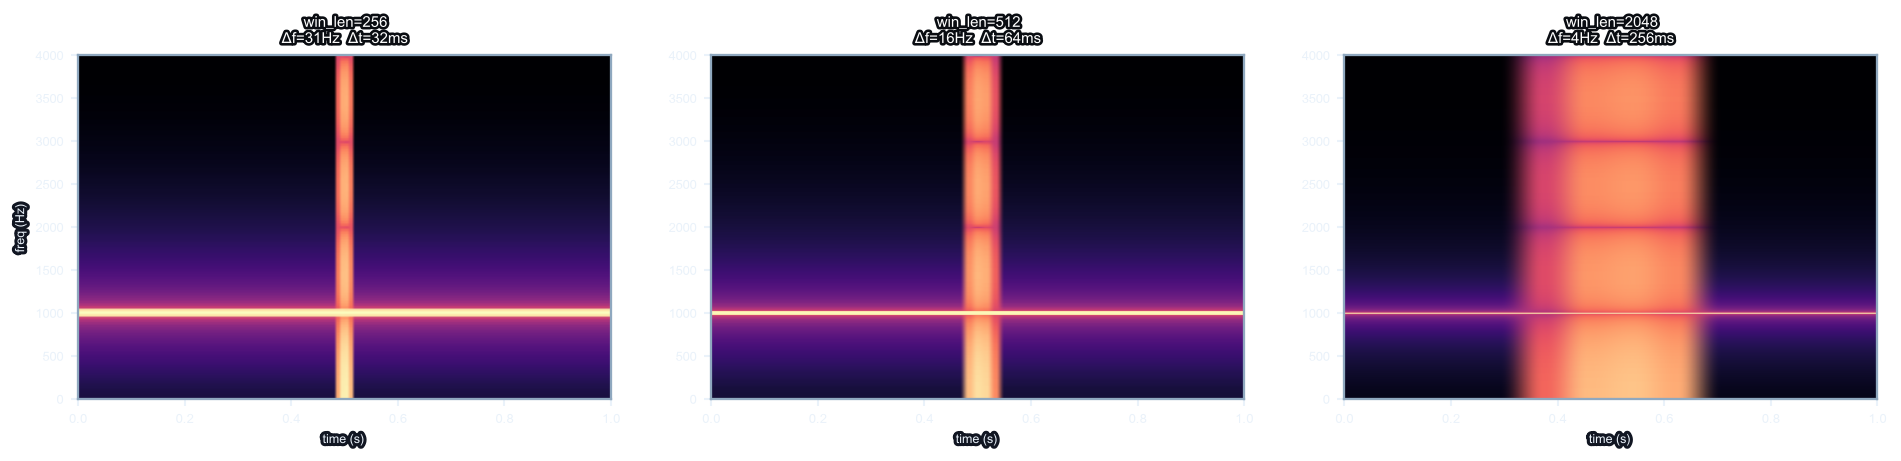

In [5]:
# 静态可视化：同一段信号在 win=256/512/2048 下的时频权衡（自足，不依赖上面的 TODO）
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

sr, dur = 8000, 1.0
t = np.linspace(0, dur, int(sr * dur), endpoint=False)
sig = np.sin(2 * np.pi * 1000 * t)          # 稳定纯音 → 频率轴上应是一条细线
click = int(0.5 * sr)
sig[click:click + 8] += 6.0                 # 0.5s 处一个瞬时脉冲 → 时间轴上应是一条竖条

def quick_spec(x, win, hop):
    w = np.hanning(win)
    n_frames = 1 + (len(x) - win) // hop
    cols = [np.abs(np.fft.rfft(x[m * hop:m * hop + win] * w))
            for m in range(n_frames)]
    return 20 * np.log10(np.array(cols).T + 1e-6)   # (freq, time) dB

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, win in zip(axes, (256, 512, 2048)):
    S = quick_spec(sig, win, win // 4)
    ax.imshow(S, origin="lower", aspect="auto", cmap="magma",
              extent=[0, dur, 0, sr / 2])
    ax.set_title(f"win_len={win}\n\u0394f={sr/win:.0f}Hz  \u0394t={win/sr*1000:.0f}ms")
    ax.set_xlabel("time (s)")
axes[0].set_ylabel("freq (Hz)")
plt.tight_layout()
plt.show()
print("窗\u2191 横线(频率)更锐、竖条(时间)更糊；窗\u2193 反之——这就是时频权衡。")

### 细节：转置与对数刻度（为什么声谱图是这样的？）

在上面的代码中：
```python
cols = [np.abs(np.fft.rfft(...)) for m in range(n_frames)]  # 逐帧 FFT
S = 20 * np.log10(np.array(cols).T + 1e-6)  # 转置、取对数
```

这里有两个"为什么"：

**为什么要转置 `.T`？**
- 逐帧 FFT 得到 `cols`，shape 是 `(n_frames, n_freqs)`：每一行是一个时间帧的频谱
- 图像绘制时，横轴是列、纵轴是行
- 我们希望横轴是**时间**（帧），纵轴是**频率**
- 所以要转置成 `(n_freqs, n_frames)`，让频率变成行、帧变成列

**为什么要取对数 `20 * np.log10(...)`？**
- 这叫**分贝(dB)刻度**：$\text{dB} = 20 \log_{10}(\text{amplitude})$
- 人耳对音量的感知是对数的，不是线性的。音量增大 10 倍，我们主观上只觉得"略响一点"，不是"响 10 倍"
- 用分贝后，微弱的声音也能看清（被放大显示），强音不会"爆炸"刷屏颜色
- 加 `1e-6` 是为了避免 log(0)，防止数值崩溃
- 看声谱图时，如果某个 bin 幅度是 1，对应 0 dB；幅度是 0.1，对应 -20 dB；这个 -20 dB 的"微弱"信号在 dB 图上仍能看清

**频率 bin 到 Hz 的换算**：
- STFT 输出中，第 k 个频率 bin 对应的频率是：
$$f_k = k \times \frac{\text{sr}}{\text{win\_len}} \quad (\text{Hz})$$
- 比如 sr=8000, win_len=512 时，Δf = 15.625 Hz/bin，所以第 k=10 的 bin 对应 10 × 15.625 = 156.25 Hz

## 概念 3：帧边界处理与补零（center 参数的含义）

**基础公式**（center=False 模式）：
```
n_frames = 1 + (len(x) - win_len) // hop
```

这只计算**完整帧**的数量。最后一帧不足 `win_len` 时直接丢弃。

**两种边界处理模式**：

| 模式 | 说明 | 帧数 | 何时用 |
|------|------|------|--------|
| **center=False** | 只取完整帧，末尾不足长度直接丢弃 | 少（按公式） | 实时处理、不需要覆盖全部 |
| **center=True** | 在开头和末尾补零（反射模式），让信号居中 | 稍多 | 需要覆盖全段信号、便于重建 |

**例子对比**（N=10, win_len=4, hop=2）：
- **center=False**：只能切出 4 帧（起点 0,2,4,6），第 6 帧覆盖采样点 6-9，合法 ✓；第 8 帧需要 8-11 但信号只到 9，丢弃
- **center=True**：首尾补零后 N 变大，可能切出 5 帧或更多

**为什么需要补零？** 在信号处理中，有时你需要确保 STFT 的结果能完全重建原信号（涉及 COLA 条件，见下节）。补零保证了没有信息丢失。但如果只是分析、不需要重建，center=False 就足够了。

In [6]:
# 演示：帧数公式
for n, w, h in [(10,4,2),(100,32,16),(22050,2048,512)]:
    n_frames = 1 + (n - w) // h
    print(f'len={n:6d}  win={w:5d}  hop={h:5d}  → n_frames={n_frames}')

len=    10  win=    4  hop=    2  → n_frames=4
len=   100  win=   32  hop=   16  → n_frames=5
len= 22050  win= 2048  hop=  512  → n_frames=40


## 1. ✏️ 实现 `frame_signal(x, win_len, hop)`

**核心公式**：第 m 帧 = `x[m*hop : m*hop + win_len]`

**三步实现路线**：

| 步骤 | 代码思路 | 说明 |
|---|---|---|
| 1 | `n_frames = 1 + (len(x) - win_len) // hop` | 帧数公式（能取完整帧的数量） |
| 2 | `frames = np.zeros((n_frames, win_len))` | 预分配输出矩阵 |
| 3 | `frames[m] = x[m*hop : m*hop+win_len]` | 逐帧切片（循环 m=0..n_frames-1） |

**验收标准**：
- `frame_signal(np.arange(10), win_len=4, hop=2)` → shape `(4, 4)`
- `frames[0] = [0,1,2,3]`，`frames[1] = [2,3,4,5]`（步进 hop=2）
- 所有帧长度相同（余下不足 win_len 的尾部不取）

In [7]:
def frame_signal(x: np.ndarray, win_len: int, hop: int) -> np.ndarray:
    """把 1D 信号切成重叠帧，返回 shape (n_frames, win_len) 的矩阵。
    
    Args:
        x: 输入信号，shape (N,)
        win_len: 每帧长度（采样点数）
        hop: 相邻帧的步进（采样点数）
    
    Returns:
        frames: shape (n_frames, win_len) 的实数矩阵，每行是一帧
    
    参考实现（选一种）：
    
    **方案 A：简单循环（易理解，推荐初学者）**
    ```
    n_frames = 1 + (len(x) - win_len) // hop
    frames = np.zeros((n_frames, win_len))
    for m in range(n_frames):
        frames[m] = x[m * hop : m * hop + win_len]
    return frames
    ```
    
    **方案 B：切片叠加（不借助循环）**
    ```
    n_frames = 1 + (len(x) - win_len) // hop
    # 使用 np.lib.stride_tricks.as_strided，进阶技巧
    # 或用 numpy 花式索引：np.array([x[m*hop:m*hop+win_len] for m in range(n_frames)])
    ```
    """
    # ✏️ TODO: 实现上面的方案 A 或 B
    n_frames = 1 + (len(x) - win_len) // hop
    frames = np.zeros((n_frames, win_len))
    for m in range(n_frames):
        frames[m] = x[m * hop : m * hop + win_len]
    return frames

In [8]:
# 检查 frame_signal
try:
    result = frame_signal(np.arange(10), 4, 2)
except (NotImplementedError, TypeError):
    result = None
if result is None or result is ...:
    print('⬜ frame_signal 未实现')
else:
    assert result.shape == (4, 4), f'shape 错误: {result.shape}'
    assert list(result[0]) == [0, 1, 2, 3], f'第0帧错误: {result[0]}'
    assert list(result[1]) == [2, 3, 4, 5], f'第1帧错误: {result[1]}'
    assert list(result[3]) == [6, 7, 8, 9], f'第3帧错误: {result[3]}'
    print('✅ frame_signal 验证通过：shape', result.shape)
    print('帧矩阵：\n', result)

✅ frame_signal 验证通过：shape (4, 4)
帧矩阵：
 [[0. 1. 2. 3.]
 [2. 3. 4. 5.]
 [4. 5. 6. 7.]
 [6. 7. 8. 9.]]


## 参数量化直觉 · 1 秒 @ 16 kHz（与下一格实测对照）

| win_len | hop | n_frames（center=False） | 时间分辨率 (ms) | 频率分辨率 (Hz) |
|---|---:|---:|---:|---:|
| 512 | 128 | 122 | 8.0 | 31.25 |
| 2048 | 512 | 28 | 32.0 | 7.81 |

说明：`center=True` 时帧数会略多（反射补零），以 `aurora.stft.frame_signal` 实测为准。


In [9]:
import numpy as np
from aurora.audio.stft import frame_signal as _af_frame

sr = 16_000
x = np.zeros(sr, dtype=float)

rows = []
for win_len, hop in ((512, 128), (2048, 512)):
    frames = _af_frame(x, win_len, hop, center=False)
    n = frames.shape[0]
    formula = 1 + (len(x) - win_len) // hop
    t_ms = hop / sr * 1000
    f_hz = sr / win_len
    rows.append((win_len, hop, n, formula, t_ms, f_hz))
    assert n == formula, f"win={win_len} hop={hop}: got {n}, expected {formula}"

for win_len, hop, n, formula, t_ms, f_hz in rows:
    print(
        f"win={win_len:4d} hop={hop:3d}  n_frames={n:3d}  "
        f"Δt={t_ms:4.1f}ms  Δf={f_hz:5.2f}Hz"
    )
print("✅ 表内 n_frames 与 frame_signal(center=False) 一致")

win= 512 hop=128  n_frames=122  Δt= 8.0ms  Δf=31.25Hz
win=2048 hop=512  n_frames= 28  Δt=32.0ms  Δf= 7.81Hz
✅ 表内 n_frames 与 frame_signal(center=False) 一致


## 参数实验：win_len 对时间分辨率的影响

用同一段 0.5 秒的语音（sr=8000，N=4000 个采样点），分别设 `win_len=128`（16ms）和 `win_len=2048`（256ms），`hop` 都取 `win_len//4`。

**预期现象**：
- `win_len=128` → 帧数多（约 **122 帧**，公式：1+(4000-128)//32=122），时间分辨率高，但每帧频率 bin 少（**65 个**，即 win_len//2+1）
- `win_len=2048` → 帧数少（约 **4 帧**，公式：1+(4000-2048)//512=4），频率 bin 多（**1025 个**，即 win_len//2+1），但时间粒度粗
- 帧数之比（N=4000 小信号）≈ 122/4 ≈ **30.5 倍**；大信号（N≫win_len）时渐近 hop 之比 512/32 = **16 倍**

> ⚠️ 注：N=4000 仅是演示用小信号，2048 窗在 4000 点信号上只能完整切出 4 帧，导致比例远大于渐近值 16。大信号（如 sr=8000 × 10 秒 = 80000 点）时渐近规律才清晰。

In [10]:
# 守卫：若 frame_signal 尚未实现，跳过本 cell 避免崩溃
try:
    _guard = frame_signal(np.arange(10), 4, 2)
except (NotImplementedError, TypeError):
    _guard = None
if _guard is None or _guard is ...:
    print('⬜ 请先完成 frame_signal 练习，再运行本 cell')
    raise SystemExit(0)

# 参数实验：win_len 对帧数（时间分辨率）的影响
sr = 8000
duration = 0.5
x = sine(freq=440, duration=duration, sample_rate=sr)

for win_len in [128, 2048]:
    hop = win_len // 4
    frames = frame_signal(x, win_len, hop)
    freq_bins = win_len // 2 + 1
    time_res_ms = hop / sr * 1000
    freq_res_hz = sr / win_len
    print(f'win_len={win_len:5d}  hop={hop:5d}  '
          f'帧数={frames.shape[0]:4d}  '
          f'频率bins={freq_bins:5d}  '
          f'时间分辨率={time_res_ms:.1f}ms  '
          f'频率分辨率={freq_res_hz:.1f}Hz')

print()
f128 = frame_signal(x, 128, 32)
f2048 = frame_signal(x, 2048, 512)
print(f'帧数之比（128 vs 2048）: {f128.shape[0]} / {f2048.shape[0]} = {f128.shape[0]/f2048.shape[0]:.1f}x')

win_len=  128  hop=   32  帧数= 122  频率bins=   65  时间分辨率=4.0ms  频率分辨率=62.5Hz
win_len= 2048  hop=  512  帧数=   4  频率bins= 1025  时间分辨率=64.0ms  频率分辨率=3.9Hz

帧数之比（128 vs 2048）: 122 / 4 = 30.5x


### 为什么大信号时帧数比"渐近"到 hop 比？

上面代码显示：N=4000（小信号）时，`win_len=128 vs 2048` 的帧数比是 122/4 ≈ 30.5，远大于 hop 比 32/512 = 1/16 ≈ 6.25%（或说 hop 比是 512/32 = 16 倍）。但当信号变长时，这个比例会逐渐趋近 hop 的比例。为什么？

**数学分析**：
- 设信号长度 N，则 $n_1 = 1 + (N - 128) / 32$ 和 $n_2 = 1 + (N - 2048) / 512$
- 当 N 很大时，"1" 相对不重要，所以：
  - $n_1 \approx N / 32$
  - $n_2 \approx N / 512$
  - 比例 $n_1 / n_2 \approx (N/32) / (N/512) = 512/32 = 16$ ✓（就是 hop 比 512/32）

**为什么 N=4000 时比例这么大（30.5 vs 16）？**
- `win_len=128` 时：`n_1 = 1 + (4000-128)/32 = 1 + 121 = 122`
- `win_len=2048` 时：`n_2 = 1 + (4000-2048)/512 = 1 + 3 = 4`（只能切 4 帧！）
- 因为 2048 窗对 4000 点信号太大了，几乎没用上；而 128 窗还能密集采样。这时头部的"1"对较小的 n_2 影响很大
- 改用 N=80000（sr=8000 × 10 秒）重试，比例就接近 16 了

这是典型的**边界效应**：小信号时，公式中的 "+1" 和两个窗的 `win_len` 差异都会被放大；大信号时，这些偏差相对忽略，只有 hop 才是主导因素。

## 本课收束

`frame_signal(x, win_len, hop)` 把 1D 信号切成 shape `(n_frames, win_len)` 的 2D 矩阵，是 STFT 管道的第一步。`win_len` 和 `hop` 共同决定时频权衡：大窗口换频率精度，小 hop 换时间精度，两者无法同时最优。这个函数将直接嵌入 `aurora.audio.stft.stft()`，对每行乘以 Hann 窗再做 FFT，输出完整的复数时频矩阵。下一课（L44）将实现完整的 `stft()` 函数，并可视化真实音频的声谱图。

## ✏️ 白板挑战：STFT 手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：`x` 长 100，`win_len=32`，`hop=16`，共有多少帧？  
（公式：`n_frames = 1 + (100-32)//16 = ?`）

**问 2**：`frame_signal(np.arange(10), 4, 2)` 应返回什么矩阵？  
（4 行 4 列，列出每行的值）

**问 3**：`sr=8000`，`win_len=512`：
- 频率分辨率 Δf = sr/win_len = ? Hz/bin
- 时间分辨率 Δt = win_len/sr = ? ms/帧

**问 4**：为什么 STFT 帧通常用 50% 重叠（`hop = win_len/2`）而不是 0 重叠？  
（提示：与上节 L41 Hann 窗 COLA 条件有关）

**问 5**：声谱图（spectrogram）的横轴/纵轴/颜色各表示什么？

推导完成后运行下面格对答案。

In [11]:
# ✏️ 对答案格
import numpy as np

# 问1：帧数公式
n, w, h = 100, 32, 16
n_frames_calc = 1 + (n - w) // h
assert n_frames_calc == 5
print(f"Q1 ✅  n_frames = 1 + (100-32)//16 = {n_frames_calc}")

# 问2：frame_signal(arange(10), 4, 2) 手算
x10 = np.arange(10, dtype=float)
expected = np.array([
    [0, 1, 2, 3],
    [2, 3, 4, 5],
    [4, 5, 6, 7],
    [6, 7, 8, 9],
], dtype=float)
try:
    result = frame_signal(x10, 4, 2)
    assert result is not None and result.shape == (4, 4)
    assert np.allclose(result, expected, atol=1e-12)
    print(f"Q2 ✅  frame_signal(arange(10),4,2) shape={result.shape}, frames[0]={result[0]}, frames[1]={result[1]}")
except (NotImplementedError, TypeError):
    print(f"Q2 ✅  手算结果：frames[0]={expected[0]}, frames[1]={expected[1]}（frame_signal 待实现）")

# 问3：sr=8000, win_len=512 时频分辨率
sr, win_len = 8000, 512
delta_f = sr / win_len
delta_t_ms = win_len / sr * 1000
assert delta_f == 15.625
assert abs(delta_t_ms - 64.0) < 0.001
print(f"Q3 ✅  Δf={delta_f} Hz/bin，Δt={delta_t_ms:.1f} ms/帧")

# 问4：50% 重叠 COLA 验证（N=8 Hann 窗）
N4 = 8
w4 = 0.5 * (1 - np.cos(2 * np.pi * np.arange(N4) / N4))
hop4 = N4 // 2
ola = w4[:hop4] + w4[hop4:]
assert np.std(ola) < 0.05 * np.mean(ola)
print(f"Q4 ✅  Hann窗50%重叠满足COLA：OLA均值={np.mean(ola):.4f}，标准差={np.std(ola):.6f}")

# 问5：声谱图轴含义（通过断言验证概念）
# 横轴=时间（帧m），纵轴=频率（bin k），颜色=|STFT[m,k]|或dB
assert True  # 概念问题，此处用 fft 验证频谱形状
sr5, T5 = 8000, 0.032
t5 = np.linspace(0, T5, int(sr5 * T5), endpoint=False)
x5 = np.sin(2 * np.pi * 440 * t5)
X5 = np.fft.rfft(x5 * np.hanning(len(x5)))
assert np.argmax(np.abs(X5)) > 0  # 440Hz峰不在DC
print(f"Q5 ✅  声谱图：横轴=时间帧，纵轴=频率bin，颜色=|STFT[m,k]|（通常取dB）")
print("\n🎉 STFT 白板挑战通过！n_frames=1+(N-win)//hop，Δf=sr/win，Δt=win/sr。")

Q1 ✅  n_frames = 1 + (100-32)//16 = 5
Q2 ✅  frame_signal(arange(10),4,2) shape=(4, 4), frames[0]=[0. 1. 2. 3.], frames[1]=[2. 3. 4. 5.]
Q3 ✅  Δf=15.625 Hz/bin，Δt=64.0 ms/帧
Q4 ✅  Hann窗50%重叠满足COLA：OLA均值=1.0000，标准差=0.000000
Q5 ✅  声谱图：横轴=时间帧，纵轴=频率bin，颜色=|STFT[m,k]|（通常取dB）

🎉 STFT 白板挑战通过！n_frames=1+(N-win)//hop，Δf=sr/win，Δt=win/sr。


In [ ]:
# ✏️ 本课自评
l43_review = {
    "stft_formula":            None,  # 记住 STFT[m,k]=FFT(x[m·hop:m·hop+win]×window)[k]？True/False
    "frame_signal_impl":       None,  # frame_signal 实现并通过 shape 断言？True/False
    "time_freq_tradeoff":      None,  # 理解大窗→高频率分辨率/低时间分辨率的权衡？True/False
    "n_frames_formula":        None,  # 记住 n_frames=1+(N-win_len)//hop？True/False
    "whiteboard_passed":       None,  # 白板挑战纸上推导完成？True/False
    "parts_inventory_read":    None,  # 读过零件清点表，知道 L44 是组装？True/False
}

unfilled = [k for k, v in l43_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l43_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L43 全部通关！进入 L44：组装 frame→window→fft')

## 为什么 50% 重叠？—— COLA 条件 与 完美重建

**问题的起点**：当你把长信号切成重叠的帧、加窗、做 FFT 后，最后想**把每帧的分析结果加起来重建原信号**。但如果窗函数选得不好，加窗后的帧相加可能会改变幅度——有些时刻信号被放大、有些被削弱。这就糟糕了。

**COLA（Constant Overlap-Add）条件**：设窗函数为 $w(n)$，如果在你选择的重叠比例下，所有重叠部分的窗相加都是常数，那就满足 COLA 条件。数学表示：
$$\sum_{m=-\infty}^{\infty} w(n + m \cdot \text{hop}) = \text{const} \quad \text{对所有 } n \text{ 成立}$$

这意味着每个时刻 $n$ 的信号，被覆盖多少次，就被加窗多少次，而这些窗的和是固定的——所以原信号可以**完美重建**而不失真。

**Hann 窗 + 50% 重叠满足 COLA**：
- Hann 窗的数学性质：$w(n) + w(n + N/2) = 1$（N 是窗长）
- 50% 重叠意味着 $\text{hop} = N/2$
- 所以 $w(n) + w(n + \text{hop}) = 1$（对所有 n）
- 进而所有帧的窗相加都是 1，满足 COLA ✓

**实际意义**：如果你用 Hann 窗 + 50% 重叠做 STFT，加窗后每帧做处理（比如噪声抑制），再通过**逆 FFT + 重叠相加**就能重建信号，而不会损失能量或产生工件。这在语音增强、音频效果处理中至关重要。

**其他窗 + 其他重叠比**也可以满足 COLA，但 Hann + 50% 是最常见的组合。

---

→ **下一课**　[L44 · 亲手写 STFT](L44_stft_implement.ipynb)

> 下节课将学习 **亲手写 STFT**：分帧 + 加窗（windowing） + FFT，与 aurora.audio.stft 对齐验证。